In [37]:
import pandas as pd
import numpy as np
import geopandas as gpd
import pickle
from sklearn.ensemble import RandomForestRegressor
from utils.data_utils import evaluate_rf
import utils.cross_validation as cval
import random 
from shapely.geometry import box

In [50]:

TEST_SIZE = 0.2
RANDOM_KEY = 21
BATCH_SIZE=16


df= pd.read_csv("fd_df_gc.csv")
ecoregions=cval.process_ecoregion("data/Ecoregions/Ecoregions2017.shp")


In [24]:
ecoregions.columns

Index(['OBJECTID', 'ECO_NAME', 'BIOME_NUM', 'BIOME_NAME', 'REALM',
       'ECO_BIOME_', 'NNH', 'ECO_ID', 'SHAPE_LENG', 'SHAPE_AREA', 'NNH_NAME',
       'COLOR', 'COLOR_BIO', 'COLOR_NNH', 'LICENSE', 'geometry'],
      dtype='str')

In [25]:
ecoregions=ecoregions[['ECO_NAME', 'geometry']]

In [26]:
df = df[~df['biome'].isin([13, 1, 2])]

df=cval.assign_spatial_groups(df, grid_size=1.0)

gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["lon"], df["lat"]),
    crs="EPSG:4326"  # WGS84
)

joined = gpd.sjoin(gdf, ecoregions, how="left", predicate="within")

In [91]:
biome_dfs = {k: v for k, v in joined.groupby('biome')}

In [100]:
biome_dfs[7]['ECO_NAME'].nunique()

3

In [90]:
print(list(biome_dfs.keys()))

[0, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]


In [80]:
test_df=biome_dfs[3]

test_df.drop(columns=['BHAGE', 'managed',
       'ownership', 'biome', 'geometry', 'index_right', 'lat', 'lon', 'DIA',
       'lon_bin', 'lat_bin'], inplace=True)

In [81]:
sets=list(set(test_df['ECO_NAME']))

In [82]:
sets

['Western Great Lakes forests',
 'New England-Acadian forests',
 'Allegheny Highlands forests',
 nan]

In [83]:
random.seed(RANDOM_KEY)
test_set = random.sample(sets, int(0.3 * len(sets)))

In [84]:
test = test_df[test_df["ECO_NAME"].isin(test_set)]
train = test_df[~test_df["ECO_NAME"].isin(test_set)]

In [85]:
y=['transformed npp', 'GC'] 

X_train=train.drop(columns=y+['PID', 'spatial_group', 'ECO_NAME'])
y_train = np.column_stack([train['transformed npp'], train['GC']])

In [86]:
y=['transformed npp', 'GC'] 

X_test= test.drop(columns=y+['PID', 'spatial_group', 'ECO_NAME'])
y_test = np.column_stack([test['transformed npp'], test['GC']])

In [87]:
fd_reg = RandomForestRegressor(random_state=RANDOM_KEY, n_jobs=2)
fd_reg.fit(X_train, y_train)


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


/home/qli/Projects/env1/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1283: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


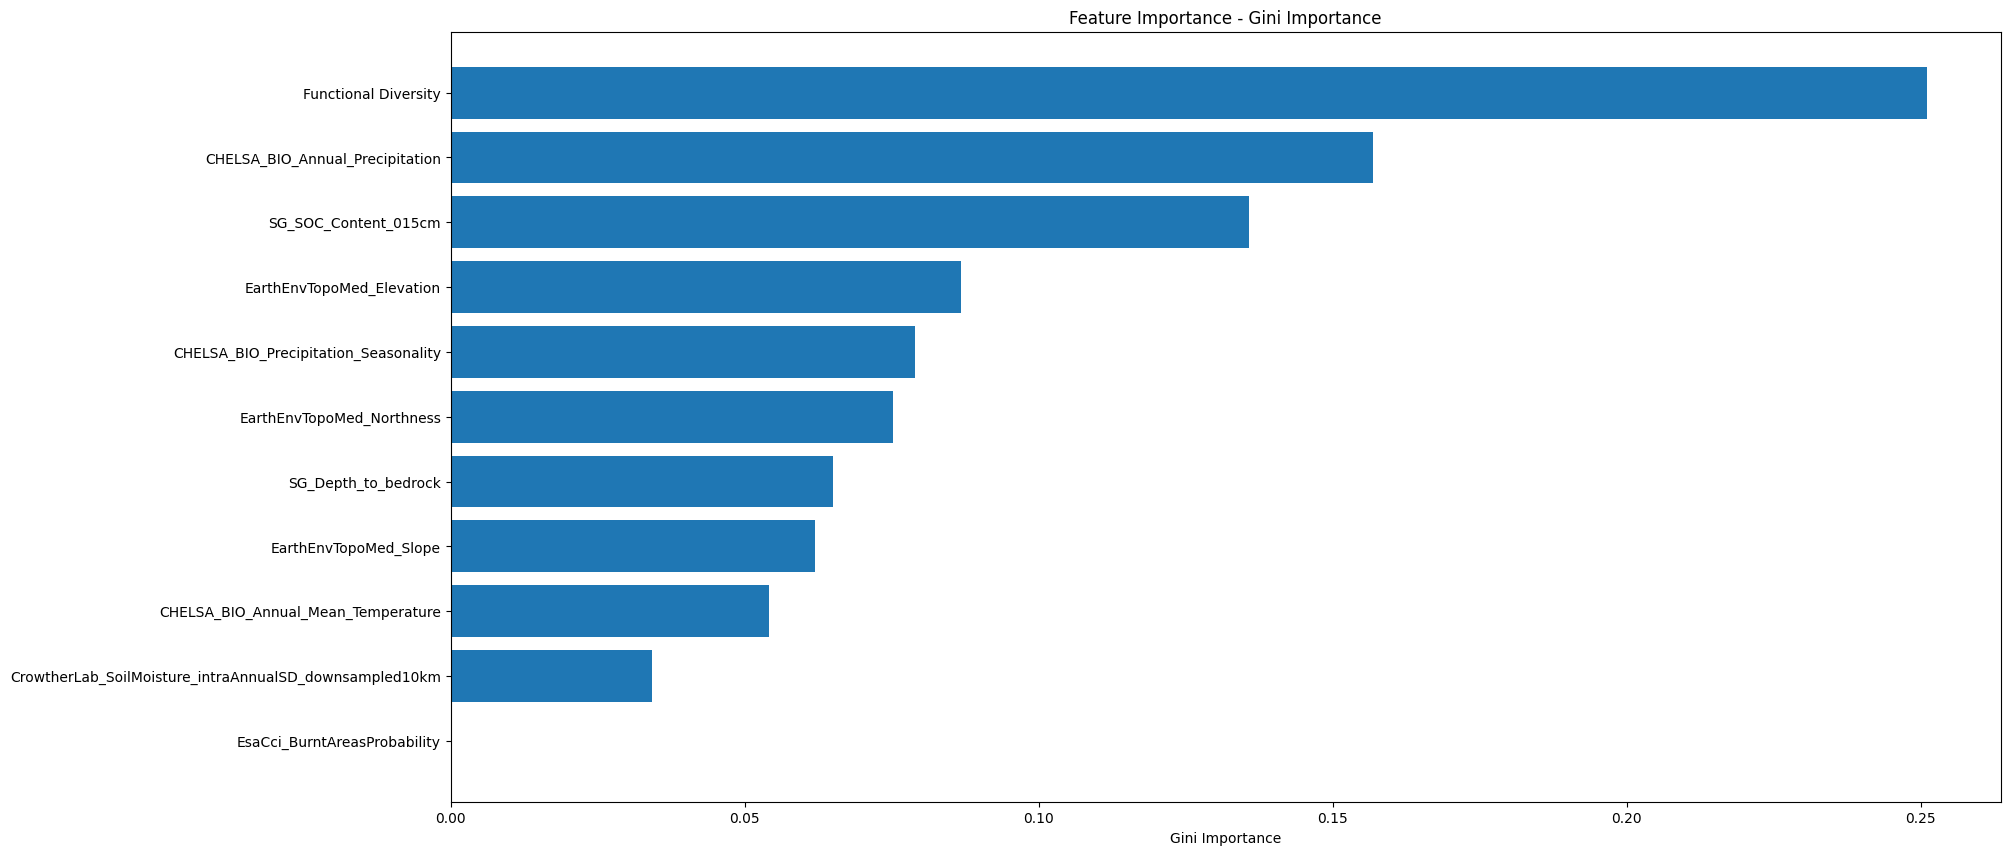

In [88]:
evaluate_rf(X_test, y_test, fd_reg, feature_names=X_train.columns, importance= True, div_type= 'f')


In [101]:
import pandas as pd
import numpy as np
import geopandas as gpd
from sklearn.ensemble import RandomForestRegressor
from utils.data_utils import evaluate_rf
import utils.cross_validation as cval
import random 
from shapely.geometry import box

import threading

def train_test_split(sub_df, random_key, test_size):
    sub_df.drop(columns=['BHAGE', 'managed',
        'ownership', 'biome', 'geometry', 'index_right', 'lat', 'lon', 'DIA',
        'lon_bin', 'lat_bin'], inplace=True)

    sets=list(set(sub_df['ECO_NAME']))

    random.seed(random_key)
    test_set = random.sample(sets, int(test_size * len(sets)))
    test = sub_df[sub_df["ECO_NAME"].isin(test_set)]
    train = sub_df[~sub_df["ECO_NAME"].isin(test_set)]

    y=['transformed npp', 'GC'] 

    X_train=train.drop(columns=y+['PID', 'spatial_group', 'ECO_NAME'])
    y_train = np.column_stack([train['transformed npp'], train['GC']])

    X_test= test.drop(columns=y+['PID', 'spatial_group', 'ECO_NAME'])
    y_test = np.column_stack([test['transformed npp'], test['GC']])

    return X_train, y_train, X_test, y_test


TEST_SIZE = 0.4
RANDOM_KEY = 21
BATCH_SIZE=16

biome_mapping = {
    0: 'Boreal and Tundra forests',
    1: 'Flooded grasslands',
    2: 'Mangroves',
    3: 'Mediterranean woodlands',
    4: 'Temperate broadleaf forests',
    5: 'Temperate conifer forests',
    6: 'Temperate grasslands',
    7: 'Tropical',
    8: 'Tropical',
    9: 'Tropical',
    10: 'Tropical',
    11: 'Boreal and Tundra forests',
    12: 'Xeric shrublands',
    13: np.nan
}


df= pd.read_csv("fd_df_gc.csv")
ecoregions=cval.process_ecoregion("data/Ecoregions/Ecoregions2017.shp")

ecoregions=ecoregions[['ECO_NAME', 'geometry']]

#Preprocessing the data for Random forest regression

df = df[~df['biome'].isin([13, 1, 2])]

df["biome"] = df["biome"].replace(biome_mapping)


In [104]:
df=cval.assign_spatial_groups(df, grid_size=1.0)

gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["lon"], df["lat"]),
    crs="EPSG:4326"  # WGS84
)

joined = gpd.sjoin(gdf, ecoregions, how="left", predicate="within")

biome_dfs = {k: v for k, v in joined.groupby('biome')}
# List of biomes: [0, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]



In [106]:
biome_dfs.keys()

dict_keys(['Boreal and Tundra forests', 'Mediterranean woodlands', 'Temperate broadleaf forests', 'Temperate conifer forests', 'Temperate grasslands', 'Tropical', 'Xeric shrublands'])

In [ ]:
biome_dfs['Mediterranean woodlands']

NameError: name 'bioem_dfs' is not defined